In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from src.mil_bioacoustics_temporal import abmil_classifier_tuned
import pickle 
from pathlib import Path
dir = Path("/idiap/temp/adeych/data")
with open(dir / "feature_banks" / "perch2-bags.pkl", "rb") as f:
    X_bags = pickle.load(f)

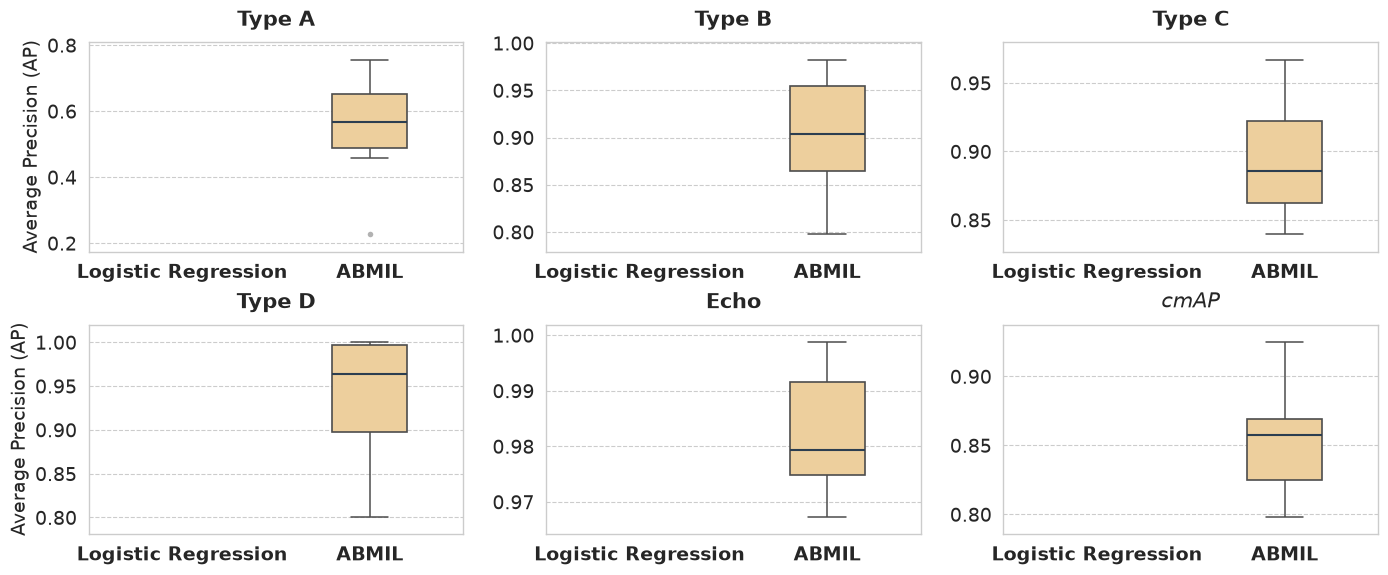

In [3]:
from src.metrics import plot_abmil_vs_perch_boxplots
import pickle
with open("/idiap/home/adeych/bat-project/results/mlp_eff_results0.pkl", "rb") as f:
    results = pickle.load(f)

plot_abmil_vs_perch_boxplots(results, results, label_names=None)

In [10]:
import numpy as np
y = np.load(dir / "feature_banks" / "labels.npy")

from src.feature_generation import pool_features

X_bags_pooled = pool_features(X_bags,encoder = 'perch2')


In [ ]:
from src.mil_bioacoustics_temporal import abmil_classifier_quick
quick_results = abmil_classifier_quick(
       X_bags_pooled, y, num_trials=1,
       variants=('ABMIL_LSTM_residual',),
   )

Starting Trial 1/1 with random_state=42...
  Evaluating model (no search): ABMIL_LSTM_residual
    Fold 1/5
    Fold 2/5
    Fold 3/5
    Fold 4/5
    Fold 5/5


In [ ]:
quick_results2 = abmil_classifier_quick(
       X_bags_pooled, y, num_trials=1,
       variants=('ABMIL',),
   )

Starting Trial 1/1 with random_state=42...
  Evaluating model (no search): ABMIL
    Fold 1/5
    Fold 2/5
    Fold 3/5
    Fold 4/5
    Fold 5/5


In [25]:
quick_results2 = abmil_classifier_quick(
       X_bags_pooled, y, num_trials=1,
       variants=('LSTM_only_residual',),
       ensemble=True,
   )

Starting Trial 1/1 with random_state=42...
  Evaluating model (no search): LSTM_only_residual
    Fold 1/5
    Fold 2/5
    Fold 3/5
    Fold 4/5
    Fold 5/5


In [27]:
quick_results3 = abmil_classifier_quick(
       X_bags_pooled, y, num_trials=1,
       variants=('LSTM_last',),
       ensemble=True,
   )

Starting Trial 1/1 with random_state=42...
  Evaluating model (no search): LSTM_last
    Fold 1/5
    Fold 2/5
    Fold 3/5
    Fold 4/5
    Fold 5/5


In [29]:
results_ABMIL = abmil_classifier_quick(
       X_bags_pooled, y, num_trials=5,
       variants=('ABMIL',),
       ensemble = False,
   )
results_ABMIL_LTSM_residual = abmil_classifier_quick(
       X_bags_pooled, y, num_trials=5,
       variants=('ABMIL_LSTM_residual',),
       ensemble = False,
   )

results_LTSM_only_residual = abmil_classifier_quick(
       X_bags_pooled, y, num_trials=5,
       variants=('LSTM_only_residual',),
       ensemble = False,
   )

results_LTSM_last =abmil_classifier_quick(
       X_bags_pooled, y, num_trials=5,
       variants=('LSTM_last',),
       ensemble = False,
   )

Starting Trial 1/5 with random_state=42...
  Evaluating model (no search): ABMIL
    Fold 1/5
    Fold 2/5
    Fold 3/5
    Fold 4/5
    Fold 5/5
Starting Trial 2/5 with random_state=43...
  Evaluating model (no search): ABMIL
    Fold 1/5
    Fold 2/5
    Fold 3/5
    Fold 4/5
    Fold 5/5
Starting Trial 3/5 with random_state=44...
  Evaluating model (no search): ABMIL
    Fold 1/5
    Fold 2/5
    Fold 3/5
    Fold 4/5
    Fold 5/5
Starting Trial 4/5 with random_state=45...
  Evaluating model (no search): ABMIL
    Fold 1/5
    Fold 2/5
    Fold 3/5
    Fold 4/5
    Fold 5/5
Starting Trial 5/5 with random_state=46...
  Evaluating model (no search): ABMIL
    Fold 1/5
    Fold 2/5
    Fold 3/5
    Fold 4/5
    Fold 5/5
Starting Trial 1/5 with random_state=42...
  Evaluating model (no search): ABMIL_LSTM_residual
    Fold 1/5
    Fold 2/5
    Fold 3/5
    Fold 4/5
    Fold 5/5
Starting Trial 2/5 with random_state=43...
  Evaluating model (no search): ABMIL_LSTM_residual
    Fold 1/5
  

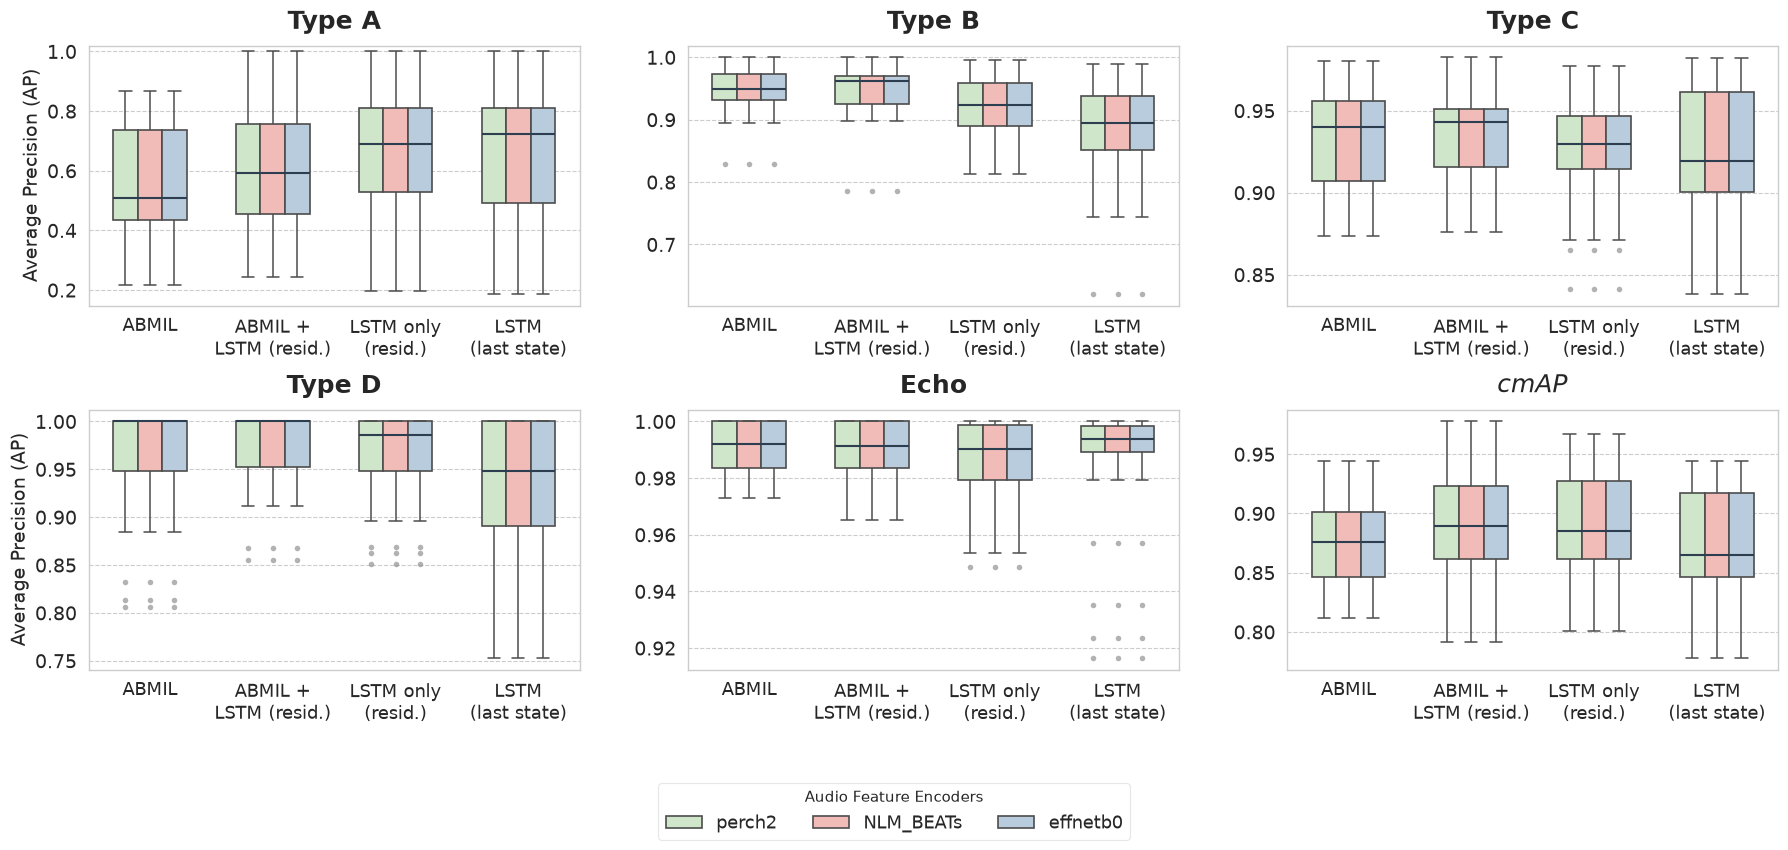

In [30]:
from src.plot_variant_comparison import plot_variant_comparison_boxplots

results_abmil_0 = {
    'perch2': results_ABMIL,
    'NLM_BEATs': results_ABMIL,
    'effnetb0': results_ABMIL,
}
results_abmil_lstm_residual_0 = {
    'perch2': results_ABMIL_LTSM_residual,
    'NLM_BEATs': results_ABMIL_LTSM_residual,
    'effnetb0': results_ABMIL_LTSM_residual,
}
results_lstm_residual_0 = {
    'perch2': results_LTSM_only_residual,
    'NLM_BEATs': results_LTSM_only_residual,
    'effnetb0': results_LTSM_only_residual,
}

results_lstm_last_0 = {
    'perch2': results_LTSM_last,
    'NLM_BEATs': results_LTSM_last,
    'effnetb0': results_LTSM_last,
}

plot_variant_comparison_boxplots(
    results_abmil_0, results_abmil_lstm_residual_0,
    results_lstm_residual_0, results_lstm_last_0,
)

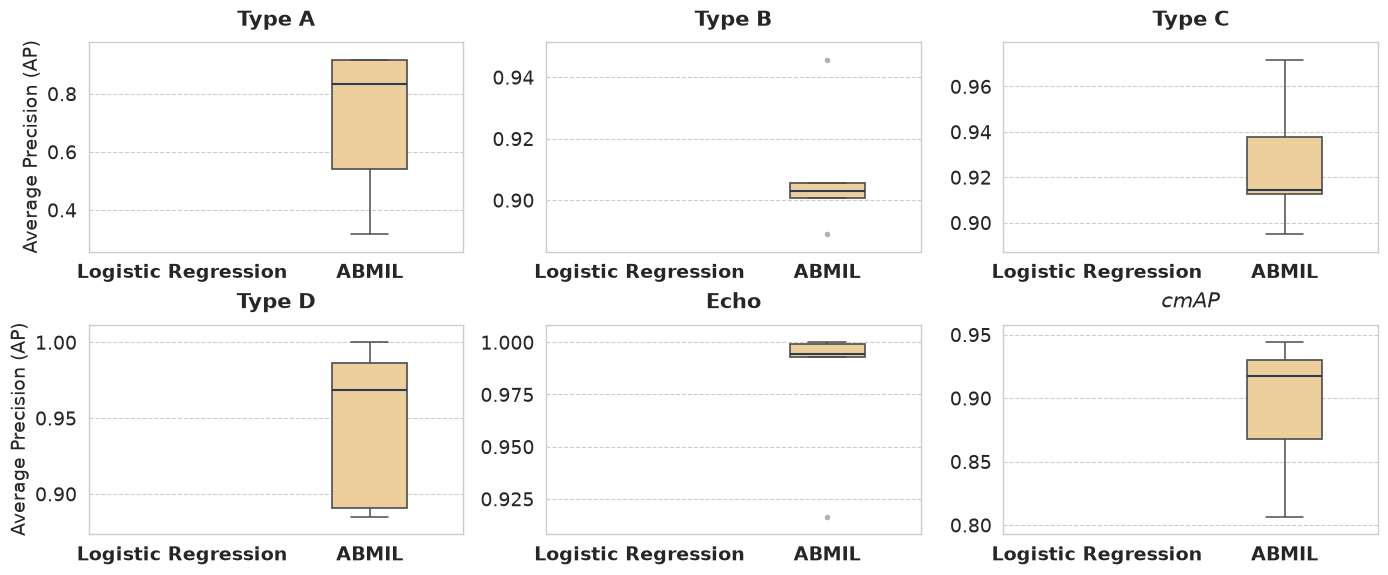

In [28]:
from src.metrics import plot_abmil_vs_perch_boxplots
plot_abmil_vs_perch_boxplots(quick_results3, quick_results, label_names=None)